In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

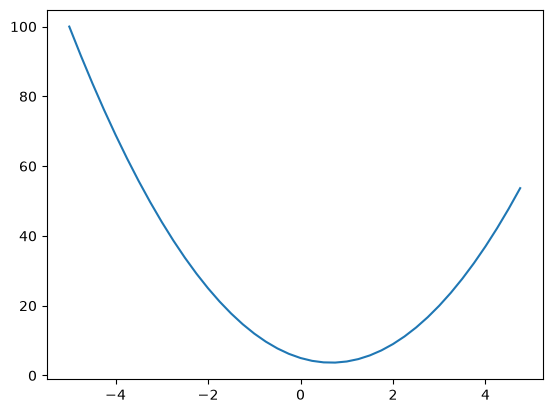

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.000001
x = 2 / 3
(f(x + h) - f(x)) / h

2.999378523327323e-06

In [6]:
a = 2.0
b = -3.0
c = 10.0
d =a * b + c
print(d)

4.0


In [7]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [8]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c
a += h
d2 = a * b + c
e = (d2 - d1) / h
print('d1', d1)
print('d2', d2)
print('slope', e)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c
b += h
d2 = a * b + c
e = (d2 - d1) / h
print('d1', d1)
print('d2', d2)
print('slope', e)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [10]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c
c += h
d2 = a * b + c
e = (d2 - d1) / h
print('d1', d1)
print('d2', d2)
print('slope', e)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [11]:
class Value:
    def __init__(self, data, __children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(__children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'only supporting int/float powers for now'
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __rsub__(self, other):
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other):
        return self * other ** -1

    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label='a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label ='e'
d = e + c; d.label='d'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [12]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


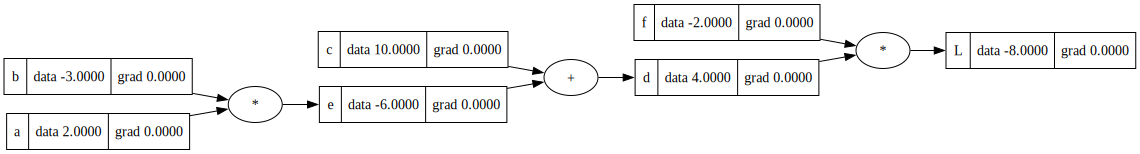

In [13]:
draw_dot(L)

In [14]:
def lol():
    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    d.data += h
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1) / h)

lol()


-2.000000000000668


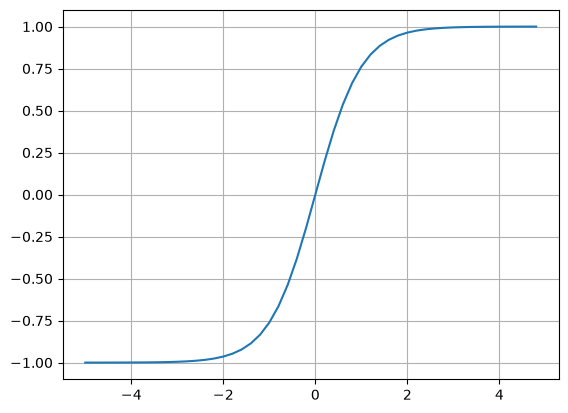

In [15]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid()

In [16]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'

#x1 * w1 + x2 * w2 + b
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh()

In [17]:
o.backward()

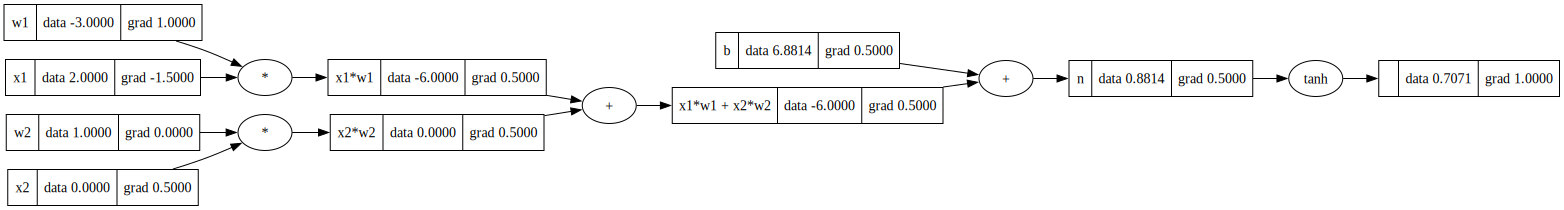

In [18]:
draw_dot(o)

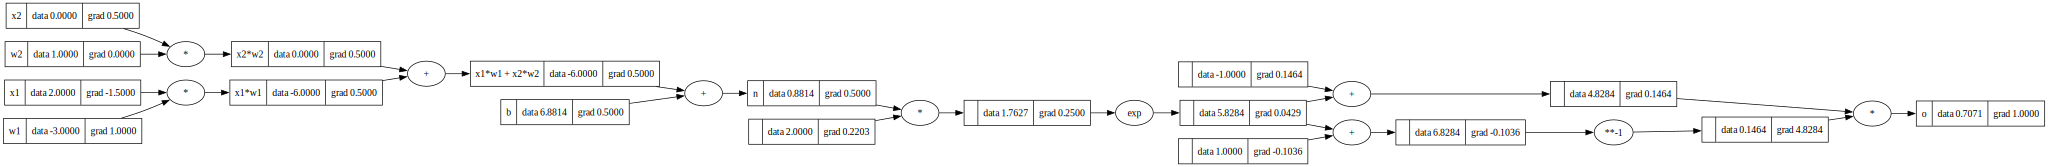

In [19]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'

#x1 * w1 + x2 * w2 + b
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'

# -------
e = (2 * n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

In [20]:
# o.grad = 1.0

# topo = []
# visited = set()
# def build_topo(v):
#     if v not in visited:
#         visited.add(v)
#         for child in v._prev:
#             build_topo(child)
#         topo.append(v)
# build_topo(o)

# for node in reversed(topo):
#     node._backward()

In [21]:
# o.grad = 1.0
# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x2w2._backward()
# x1w1._backward()


In [22]:
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad

# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad

In [23]:
# x2w2.grad=0.5
# x1w1.grad=0.5

In [24]:
# x1w1x2w2.grad=0.5
# b.grad=0.5

In [25]:
# n.grad = 0.5

In [26]:
# o.grad=1.0
# 1 - o.data ** 2

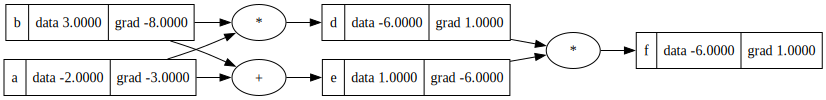

In [27]:
a = Value(-2.0, label='a')
b = Value(3.0, label = 'b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)

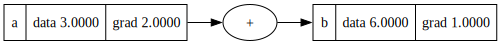

In [28]:
a = Value(3.0, label='a')
b = a + a; b.label='b'

b.backward()
draw_dot(b)

In [29]:
a = Value(2.0)
print(a + 1)
print(a * 2)
a * 2

Value(data=3.0)
Value(data=4.0)


Value(data=4.0)

In [30]:
a = Value(2.0)
a.exp()

Value(data=7.38905609893065)

In [31]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [32]:
import torch
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('--------')
print('w2', w2.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('x1', x1.grad.item())


0.7071066904050358
--------
w2 0.0
x2 0.5000001283844369
w1 1.0000002567688737
x1 -1.5000003851533106


In [33]:
o.item()

0.7071066904050358

In [34]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    
    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
    

Value(data=0.39649426676592214)

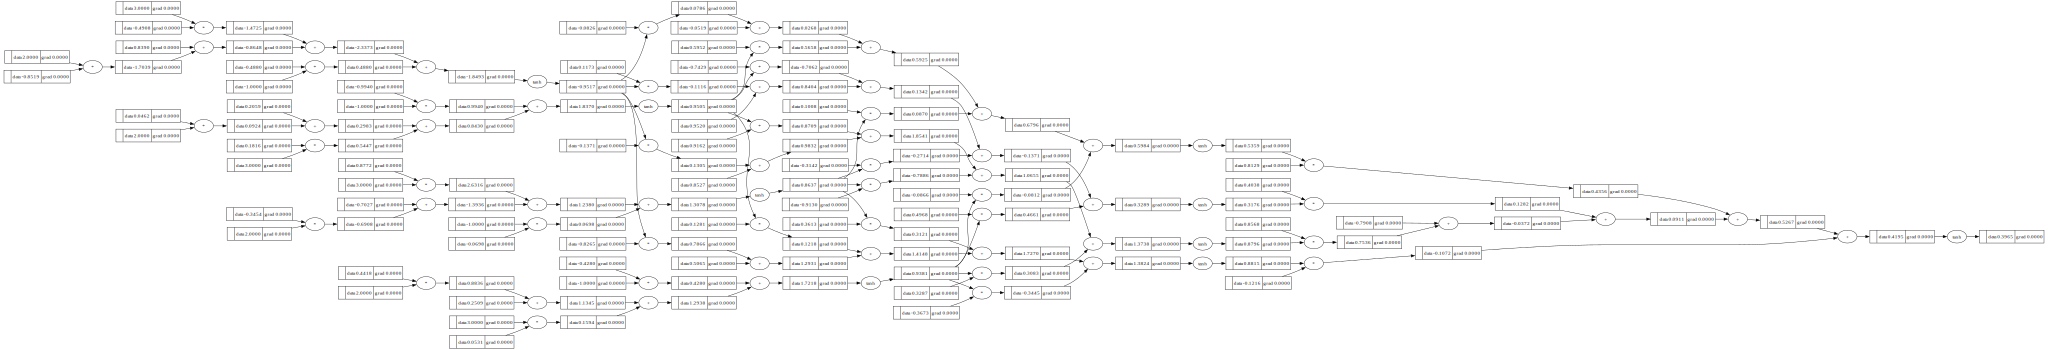

In [35]:
draw_dot(n(x))

In [36]:
n.parameters()

[Value(data=-0.8519277265281926),
 Value(data=-0.4908375207121225),
 Value(data=-0.48798552813593377),
 Value(data=0.8390421761490987),
 Value(data=0.04619633145370061),
 Value(data=0.18157034589058552),
 Value(data=-0.9940123772278502),
 Value(data=0.2059269239813657),
 Value(data=-0.34542126300991005),
 Value(data=0.8771985817528434),
 Value(data=-0.06983171353486917),
 Value(data=-0.7027479628791564),
 Value(data=0.4417966965332534),
 Value(data=0.05312329486508527),
 Value(data=-0.42795724075135033),
 Value(data=0.25085776283366235),
 Value(data=-0.1371007652384877),
 Value(data=0.9162378593345726),
 Value(data=-0.9130217720536917),
 Value(data=0.32867314377968593),
 Value(data=0.8527029232858585),
 Value(data=0.11729139139444644),
 Value(data=-0.7429410447732887),
 Value(data=-0.31419597761815776),
 Value(data=0.4968173151858759),
 Value(data=0.9520446218008725),
 Value(data=-0.08260649661169528),
 Value(data=0.5952355786002166),
 Value(data=0.10076007774042184),
 Value(data=-0.08

In [37]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
ypred

[Value(data=0.39649426676592214),
 Value(data=0.08096032174515116),
 Value(data=-0.34822967590765713),
 Value(data=0.5092462123326558)]

In [38]:
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.1983382227110653)

In [ ]:
n.layers[0].neurons[0].w[0].grad

-0.06036909421221841

In [64]:
n.layers[0].neurons[0].w[0].data

-0.834365356665896

In [88]:
loss.backward()

In [89]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [43]:
n.layers[0].neurons[0].w[0].data

-0.8513240355860704

In [96]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)


0 2.47414448653476e-16
1 2.47414448653476e-16
2 2.47414448653476e-16
3 2.47414448653476e-16
4 2.47414448653476e-16
5 2.47414448653476e-16
6 2.47414448653476e-16
7 2.47414448653476e-16
8 2.47414448653476e-16
9 2.47414448653476e-16
10 2.47414448653476e-16
11 2.47414448653476e-16
12 2.47414448653476e-16
13 2.47414448653476e-16
14 2.47414448653476e-16
15 2.47414448653476e-16
16 2.47414448653476e-16
17 2.47414448653476e-16
18 2.47414448653476e-16
19 2.47414448653476e-16


In [97]:
ypred

[Value(data=0.9999999896743289),
 Value(data=-0.9999999999999999),
 Value(data=-0.9999999999999988),
 Value(data=0.9999999881342946)]